In [1]:
# Titanic data set
import os # where the path is
import numpy as np # mathematical calculation
import pandas as pd # data manipulation
import matplotlib.pyplot as plt # data visuliasation
import seaborn as sns # data visuliasation
sns.set  
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows',500)
pd.set_option('display.max_columns',50)
pd.set_option('display.width',1000)

In [2]:
df1 = pd.read_csv("titanic_train.csv")
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df1.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype='object')

In [4]:
df1 = df1[[col for col in df1.columns if col != 'Survived'] + ['Survived']]
df1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [5]:
df1.shape

(891, 12)

In [6]:
df2 = pd.read_csv("titanic_test.csv")
df2.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
df2.shape

(418, 11)

In [8]:
df2.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype='object')

In [9]:
df2['Survived'] = pd.NA  # or use np.nan if using NumPy


In [10]:
df3 = pd.concat([df1, df2], axis=0, ignore_index=True)
df3.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [11]:
df3.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
1304,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,<NA>
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,<NA>
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,<NA>
1307,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,<NA>
1308,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C,<NA>


In [12]:
df3.shape

(1309, 12)

In [13]:
df3.isnull().sum()/len(df3)

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.200917
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000764
Cabin          0.774637
Embarked       0.001528
Survived       0.319328
dtype: float64

# # Step 3: Handle missing values
Fill Age with median

In [14]:

df3['Age'] = df3['Age'].fillna(df3['Age'].median())
df3.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,2.294882,29.503186,0.498854,0.385027,33.295479
std,378.020061,0.837836,12.905241,1.041658,0.865560,51.758668
min,1.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,655.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,3.000000,35.000000,1.000000,0.000000,31.275000
max,1309.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [15]:
# Fill Embarked with mode
df3['Embarked'] = df3['Embarked'].fillna(df3['Embarked'].mode()[0])

In [16]:
# Fill Fare (only in test) with median
df3['Fare'] = df3['Fare'].fillna(df3['Fare'].median())

In [17]:
# Step 4: Encode categorical variables
df3 = pd.get_dummies(df3, columns=['Sex', 'Embarked'], drop_first=True)

In [18]:
df3.head()

,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Survived,Sex_male,Embarked_Q,Embarked_S
0,1,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,0,True,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,1,False,False,False
2,3,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,False,False,True
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,1,False,False,True
4,5,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,0,True,False,True


In [19]:
df3.drop(columns=['Name', 'Ticket', 'Cabin','PassengerId'], inplace=True)

In [20]:
df3.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived', 'Sex_male', 'Embarked_Q', 'Embarked_S'], dtype='object')

In [21]:
# Step 5: Split back into train and test
train_df3 = df3[df3['Survived'].notna()].copy() 

In [22]:
train_df3.head()

,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


In [23]:
test_df3 = df3[df3['Survived'].isna()].copy()

In [24]:
test_df3.head()

,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_male,Embarked_Q,Embarked_S
891,3,34.5,0,0,7.8292,<NA>,True,True,False
892,3,47.0,1,0,7.0000,<NA>,False,False,True
893,2,62.0,0,0,9.6875,<NA>,True,True,False
894,3,27.0,0,0,8.6625,<NA>,True,False,True
895,3,22.0,1,1,12.2875,<NA>,False,False,True


In [25]:
# Step 8: Prepare features and labels
X = train_df3.drop(columns=['Survived'])
X.head()


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [26]:
y = train_df3['Survived'].astype(int)
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [27]:
X_test_final = test_df3.drop(columns=['Survived'])

In [28]:
# Step 9: Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

In [29]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [30]:
# Step 10: Apply SMOTE to handle imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)


In [31]:
# Step 11: Train/test split (for validation)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [32]:
# Step 12: Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [33]:
# Step 13: Evaluate
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("Validation Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Validation Accuracy: 0.8090909090909091
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       103
           1       0.80      0.85      0.83       117

    accuracy                           0.81       220
   macro avg       0.81      0.81      0.81       220
weighted avg       0.81      0.81      0.81       220



In [34]:
# Step 14: Save model and scaler
import joblib
joblib.dump(model, 'titanic_logistic_model_smote.pkl')
joblib.dump(scaler, 'titanic_scaler_smote.pkl')

['titanic_scaler_smote.pkl']

# EDA: VISUALIZATION:

What was the overall survival rate?
Chart Type: Pie chart or bar plot

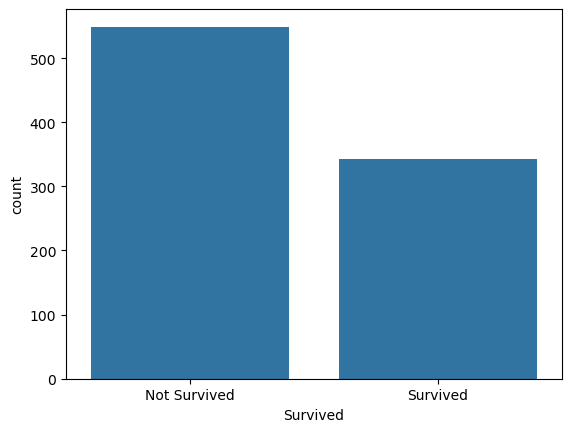

In [35]:
sns.countplot(x='Survived', data=train_df3)
plt.xticks([0,1], ['Not Survived', 'Survived'])
plt.show()


# Did gender influence survival rate?
Chart Type: Grouped bar plot / stacked bar chart

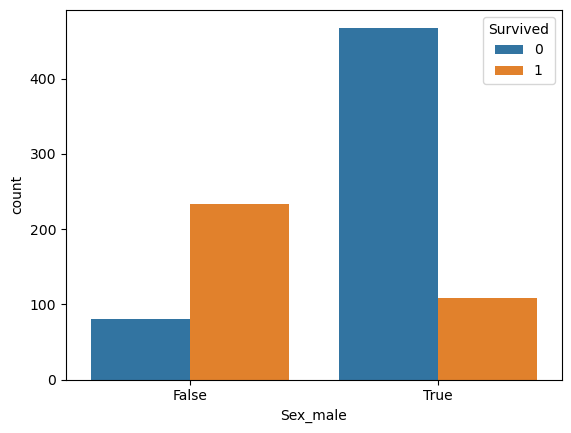

In [36]:
sns.countplot(x='Sex_male', hue='Survived', data=train_df3)
plt.show()

In [37]:
train_df3.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived', 'Sex_male', 'Embarked_Q', 'Embarked_S'], dtype='object')

# How did passenger class (Pclass) affect survival?
Chart Type: Grouped bar plot

In [38]:
sns.countplot(x='Pclass', hue='Survived', data=train_df3)


<Axes: xlabel='Pclass', ylabel='count'>

# What was the age distribution of survivors and non-survivors?
Chart Type: KDE plot or histogram

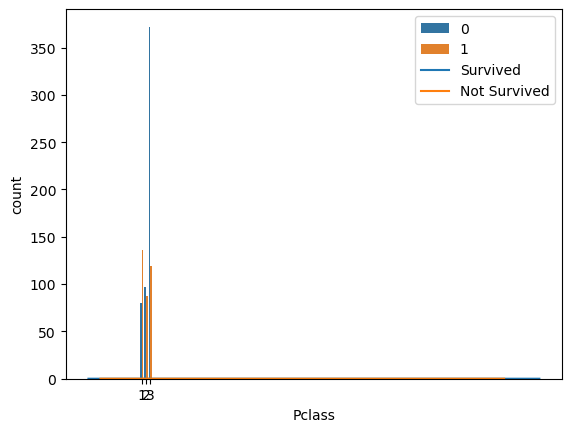

In [39]:
sns.kdeplot(train_df3[train_df3['Survived']==1]['Age'], label='Survived')
sns.kdeplot(train_df3[train_df3['Survived']==0]['Age'], label='Not Survived')
plt.legend()
plt.show()

#  Did family size impact survival?
Chart Type: Bar plot or box plot

Derived Feature: FamilySize = SibSp + Parch + 1

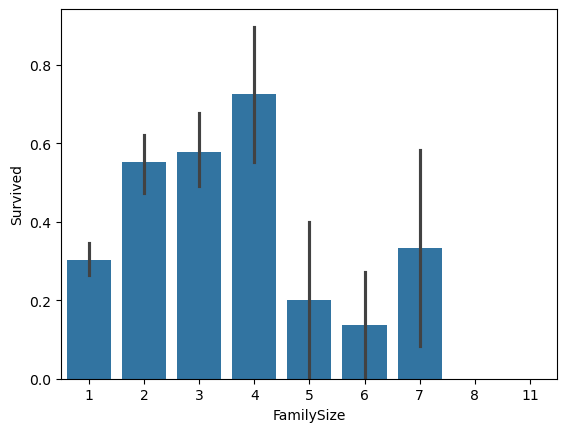

In [40]:
train_df3['FamilySize'] = train_df3['SibSp'] + train_df3['Parch'] + 1
sns.barplot(x='FamilySize', y='Survived', data=train_df3)
plt.show()

# Was there a relationship between fare and survival?
Chart Type: Box plot or violin plot

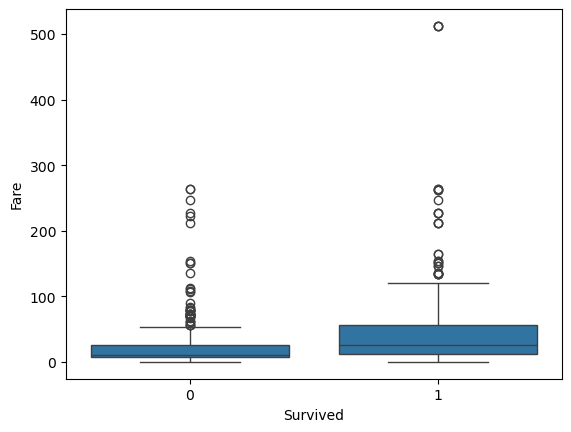

In [41]:
sns.boxplot(x='Survived', y='Fare', data=train_df3)
plt.show()

# How did embarkation port affect survival?
Chart Type: Grouped bar plot



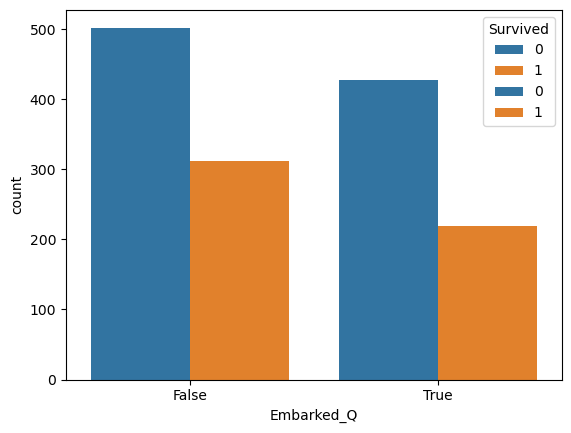

In [42]:
sns.countplot(x='Embarked_Q', hue='Survived', data=train_df3)
sns.countplot(x='Embarked_S', hue='Survived', data=train_df3)
plt.show()

# Which combinations of class and gender had higher survival?
Chart Type: Heatmap or grouped bar chart

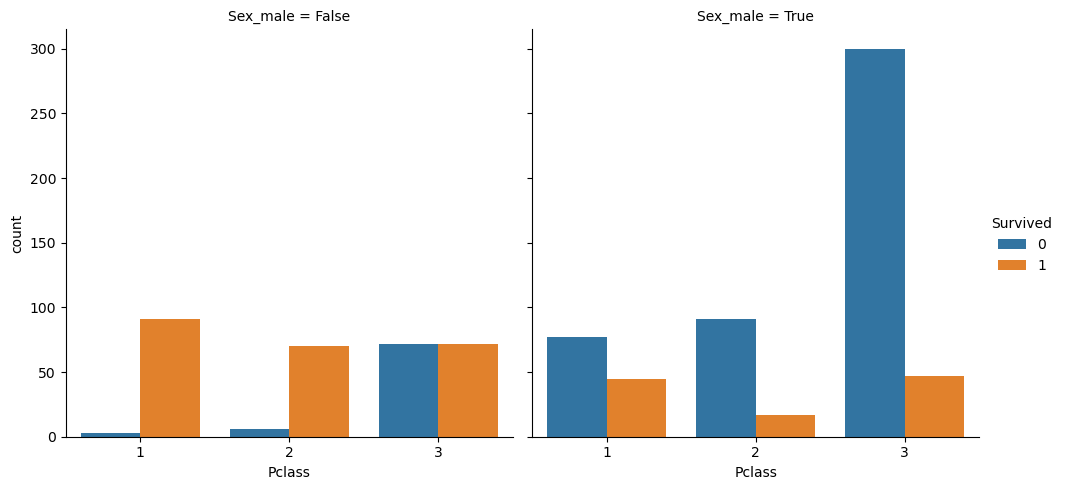

In [43]:
sns.catplot(x='Pclass', hue='Survived', col='Sex_male', kind='count', data=train_df3)
plt.show()

#  Were younger passengers more likely to survive in each class?
Chart Type: Box plot per class split by survival

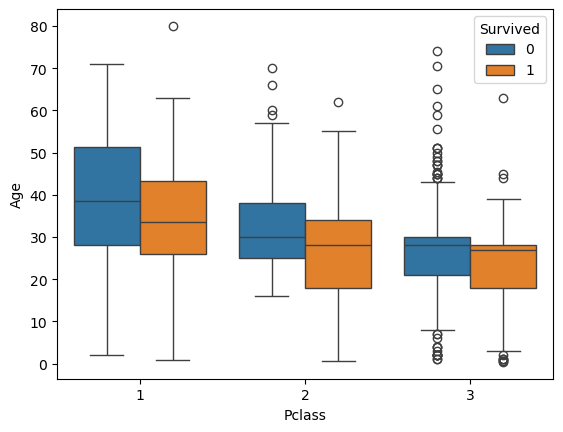

In [44]:
sns.boxplot(x='Pclass', y='Age', hue='Survived', data=train_df3)
plt.show()

#  Does ticket fare vary across classes and survival?
Chart Type: Violin plot

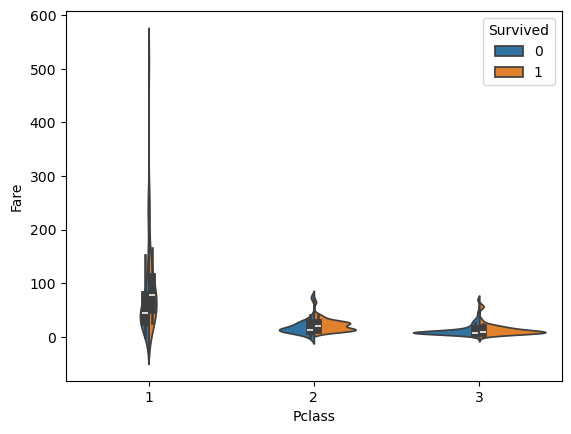

In [45]:
sns.violinplot(x='Pclass', y='Fare', hue='Survived', data=train_df3, split=True)
plt.show()

In [46]:
train_df3.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'FamilySize'], dtype='object')

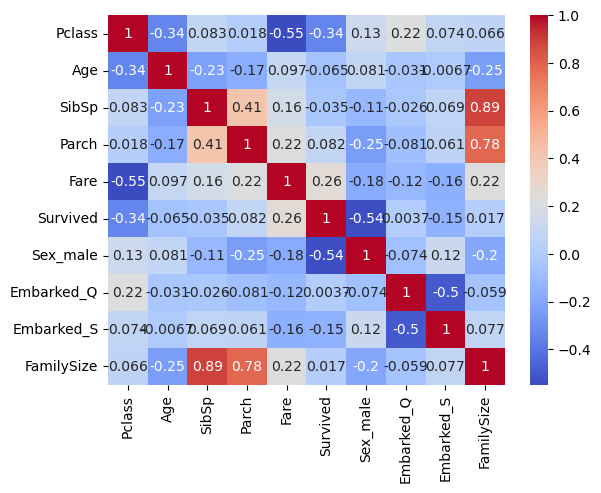

In [47]:
sns.heatmap(train_df3.corr(), annot=True, cmap='coolwarm')
plt.show()

| Question                     | Chart Type        |
| ---------------------------- | ----------------- |
| Overall survival             | Pie / bar         |
| Gender vs survival           | Grouped bar       |
| Class vs survival            | Grouped bar       |
| Age vs survival              | KDE / histogram   |
| Family size vs survival      | Bar plot          |
| Fare vs survival             | Box / violin      |
| Embarkation port vs survival | Grouped bar       |
| Gender + Class               | Catplot / heatmap |
| Age by class & survival      | Boxplot           |
| Fare by class & survival     | Violin            |


# Define Function for Chi-Square Test

In [48]:
from scipy.stats import chi2_contingency
def chi_square_test(cat_var, target='Survived'):
    contingency_table = pd.crosstab(train_df3[cat_var], train_df3[target])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-Square Test for {cat_var} vs {target}")
    print("Chi2 Statistic:", chi2)
    print("Degrees of Freedom:", dof)
    print("P-value:", p)
    print("Significant?" , "Yes " if p < 0.05 else "No ")
    print("-" * 40)


In [49]:
chi_square_test('Sex_male')

Chi-Square Test for Sex_male vs Survived
Chi2 Statistic: 260.71702016732104
Degrees of Freedom: 1
P-value: 1.1973570627755645e-58
Significant? Yes 
----------------------------------------


In [50]:
chi_square_test('Pclass')
chi_square_test('Embarked_Q')
chi_square_test('Embarked_S')

Chi-Square Test for Pclass vs Survived
Chi2 Statistic: 102.88898875696056
Degrees of Freedom: 2
P-value: 4.549251711298793e-23
Significant? Yes 
----------------------------------------
Chi-Square Test for Embarked_Q vs Survived
Chi2 Statistic: 0.0
Degrees of Freedom: 1
P-value: 1.0
Significant? No 
----------------------------------------
Chi-Square Test for Embarked_S vs Survived
Chi2 Statistic: 19.279400244953347
Degrees of Freedom: 1
P-value: 1.1291808110540787e-05
Significant? Yes 
----------------------------------------
